In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/m1-data/M1_data.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv('/kaggle/input/m1-data/M1_data.csv')
df.head()

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_neural,f_synergy,f_performanceloss,m1_consideration,m1_purchase,gender,age_group,income_group,status,domain
0,No,4,8,PC,0,No,5,4,3,4,...,2,1,1,1,Yes,Male,2,2,Student,Science
1,Yes,2,4,PC,1,No,5,5,5,3,...,2,2,4,2,No,Male,2,3,Employed,Finance
2,Yes,5,6,PC,0,No,3,4,2,4,...,2,2,2,4,Yes,Male,2,2,Student,IT & Technology
3,Yes,2,6,Apple,4,No,4,3,3,4,...,4,4,3,2,No,Female,2,2,Student,Arts & Culture
4,Yes,4,4,Apple,7,Yes,5,3,3,4,...,3,4,4,4,Yes,Male,5,7,Employed,Hospitality


In [5]:
df.shape

(133, 22)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   trust_apple          133 non-null    object
 1   interest_computers   133 non-null    int64 
 2   age_computer         133 non-null    int64 
 3   user_pcmac           133 non-null    object
 4   appleproducts_count  133 non-null    int64 
 5   familiarity_m1       133 non-null    object
 6   f_batterylife        133 non-null    int64 
 7   f_price              133 non-null    int64 
 8   f_size               133 non-null    int64 
 9   f_multitasking       133 non-null    int64 
 10  f_noise              133 non-null    int64 
 11  f_performance        133 non-null    int64 
 12  f_neural             133 non-null    int64 
 13  f_synergy            133 non-null    int64 
 14  f_performanceloss    133 non-null    int64 
 15  m1_consideration     133 non-null    int64 
 16  m1_purch

In [7]:
df.describe()

,interest_computers,age_computer,appleproducts_count,f_batterylife,f_price,f_size,f_multitasking,f_noise,f_performance,f_neural,f_synergy,f_performanceloss,m1_consideration,age_group,income_group
count,133.00000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,3.81203,2.827068,2.609023,4.526316,3.872180,3.157895,4.120301,3.729323,4.398496,3.165414,3.466165,3.375940,3.609023,2.969925,2.969925
std,0.96256,2.444881,1.898303,0.723826,0.995547,1.166724,0.798081,1.129010,0.768113,1.142700,1.276530,1.125473,1.242155,1.898723,2.014868
min,2.00000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.00000,1.000000,1.000000,4.000000,3.000000,2.000000,4.000000,3.000000,4.000000,2.000000,3.000000,3.000000,3.000000,2.000000,1.000000
50%,4.00000,3.000000,3.000000,5.000000,4.000000,3.000000,4.000000,4.000000,5.000000,3.000000,4.000000,4.000000,4.000000,2.000000,2.000000
75%,5.00000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,5.000000,3.000000,4.000000
max,5.00000,9.000000,8.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,7.000000


In [8]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [9]:
df.isnull().sum()

trust_apple            0
interest_computers     0
age_computer           0
user_pcmac             0
appleproducts_count    0
familiarity_m1         0
f_batterylife          0
f_price                0
f_size                 0
f_multitasking         0
f_noise                0
f_performance          0
f_neural               0
f_synergy              0
f_performanceloss      0
m1_consideration       0
m1_purchase            0
gender                 0
age_group              0
income_group           0
status                 0
domain                 0
dtype: int64

In [10]:
df['purchased'] = df['m1_purchase'].apply(lambda x: 1 if x== "Yes" else 0)
df['trust_apple'] = df['trust_apple'].apply(lambda x: 1 if x== "Yes" else 0)
df['user_pcmac'] = df['user_pcmac'].apply(lambda x: 1 if x== "Apple" else 0)
df['familiarity_m1'] = df['familiarity_m1'].apply(lambda x: 1 if x== "Yes" else 0)
df['gender'] = df['gender'].apply(lambda x: 1 if x== "Male" else 0)

In [11]:
df.head()

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_synergy,f_performanceloss,m1_consideration,m1_purchase,gender,age_group,income_group,status,domain,purchased
0,0,4,8,0,0,0,5,4,3,4,...,1,1,1,Yes,1,2,2,Student,Science,1
1,1,2,4,0,1,0,5,5,5,3,...,2,4,2,No,1,2,3,Employed,Finance,0
2,1,5,6,0,0,0,3,4,2,4,...,2,2,4,Yes,1,2,2,Student,IT & Technology,1
3,1,2,6,1,4,0,4,3,3,4,...,4,3,2,No,0,2,2,Student,Arts & Culture,0
4,1,4,4,1,7,1,5,3,3,4,...,4,4,4,Yes,1,5,7,Employed,Hospitality,1


**EDA**

In [12]:
df.drop(columns=['m1_purchase'], inplace=True)
df.head()

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_neural,f_synergy,f_performanceloss,m1_consideration,gender,age_group,income_group,status,domain,purchased
0,0,4,8,0,0,0,5,4,3,4,...,2,1,1,1,1,2,2,Student,Science,1
1,1,2,4,0,1,0,5,5,5,3,...,2,2,4,2,1,2,3,Employed,Finance,0
2,1,5,6,0,0,0,3,4,2,4,...,2,2,2,4,1,2,2,Student,IT & Technology,1
3,1,2,6,1,4,0,4,3,3,4,...,4,4,3,2,0,2,2,Student,Arts & Culture,0
4,1,4,4,1,7,1,5,3,3,4,...,3,4,4,4,1,5,7,Employed,Hospitality,1


**Column categories**

- **Numerical**: age_computer, appleproducts_count
- **Categorical**: trust_apple, user_pcmac, income_group, age_group, gender, interest_computers, familiarity_m1, f_batterylife, f_price, f_size, f_multitasking, f_performance, f_noise, f_neural, f_synergy, f_performanceloss, m1_consideration, status, domain
- **Target**: Purchased

**Uni-variate Analysis.**

**age_computer**

Conclusion:
- moderately right skewed

In [13]:
df['age_computer'].describe()

count    125.000000
mean       2.808000
std        2.477954
min        0.000000
25%        0.000000
50%        3.000000
75%        5.000000
max        9.000000
Name: age_computer, dtype: float64

<Axes: ylabel='Frequency'>

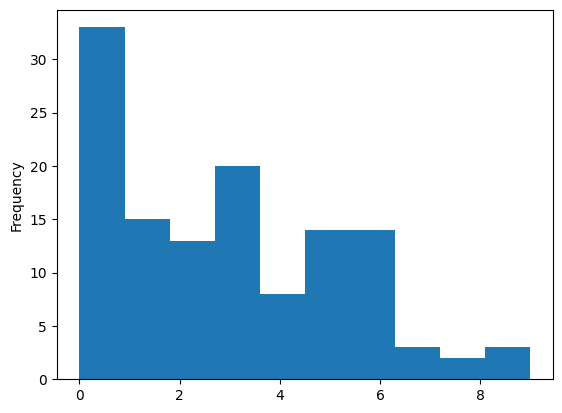

In [14]:
df['age_computer'].plot(kind='hist')

<Axes: ylabel='Density'>

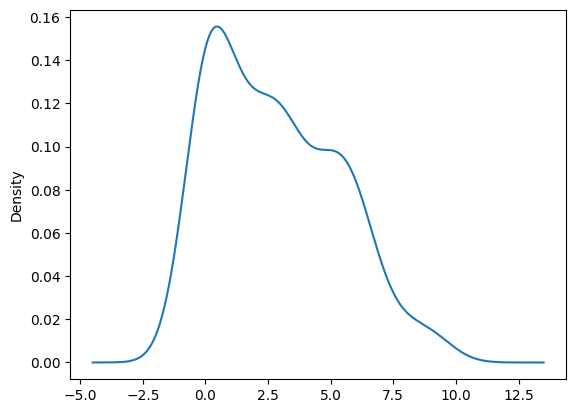

In [15]:
df['age_computer'].plot(kind='kde')

In [16]:
df['age_computer'].skew()

np.float64(0.5405022606744588)

In [17]:
df['age_computer'].isnull().sum()

np.int64(0)

<Axes: >

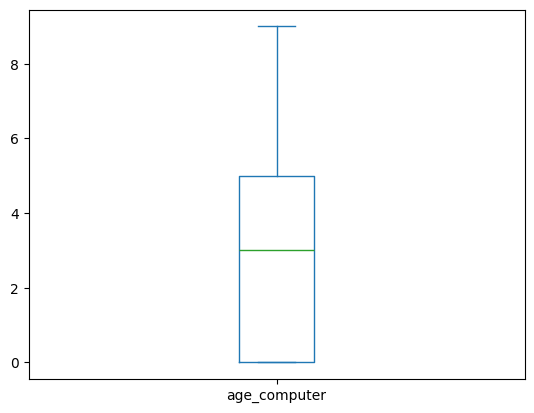

In [18]:
df['age_computer'].plot(kind='box')

**appleproducts_count**

conclusions:
- modrately right skewed
- has 1 outlier

In [19]:
df['appleproducts_count'].describe()

count    125.000000
mean       2.520000
std        1.856115
min        0.000000
25%        1.000000
50%        3.000000
75%        3.000000
max        8.000000
Name: appleproducts_count, dtype: float64

In [20]:
df['appleproducts_count'].value_counts()

appleproducts_count
3    36
0    23
2    21
4    16
1    15
7     5
5     5
6     3
8     1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

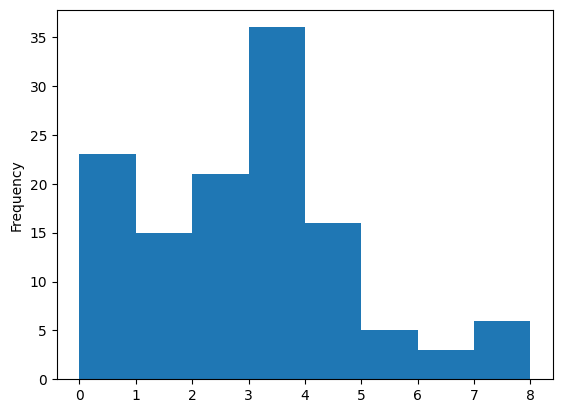

In [21]:
df['appleproducts_count'].plot(kind='hist',bins=8)

<Axes: ylabel='Density'>

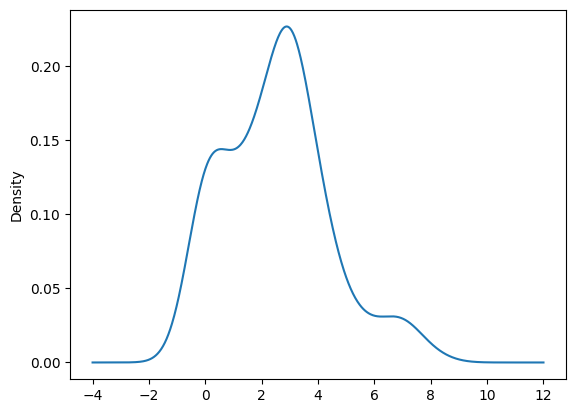

In [22]:
df['appleproducts_count'].plot(kind='kde')

In [23]:
df['appleproducts_count'].skew()

np.float64(0.5754498498321104)

<Axes: >

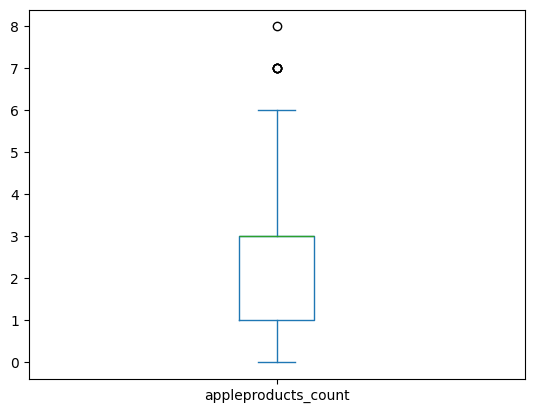

In [24]:
df['appleproducts_count'].plot(kind='box')

In [25]:
df[df['appleproducts_count']>6]

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_neural,f_synergy,f_performanceloss,m1_consideration,gender,age_group,income_group,status,domain,purchased
4,1,4,4,1,7,1,5,3,3,4,...,3,4,4,4,1,5,7,Employed,Hospitality,1
6,1,3,2,1,7,0,4,3,4,5,...,3,3,2,3,1,6,7,Employed,IT & Technology,1
9,1,5,0,1,7,1,5,3,5,5,...,3,5,5,5,1,4,6,Employed,Hospitality,1
15,1,4,4,1,7,1,5,3,3,4,...,3,4,4,4,1,5,7,Employed,Hospitality,0
130,1,4,0,1,8,1,5,4,3,5,...,4,4,5,5,0,2,3,Student,Marketing,1
132,1,5,2,1,7,0,4,3,4,4,...,4,1,3,5,1,5,7,Employed,Finance,0


**trust_apple**
Conclusions:
- most people trust the Apple brand

<Axes: xlabel='trust_apple'>

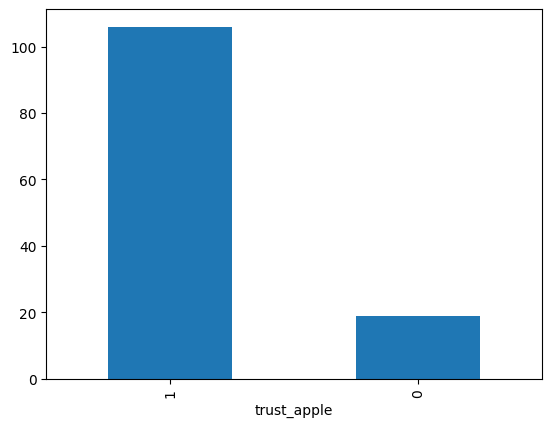

In [26]:
df['trust_apple'].value_counts().plot(kind='bar')

**user_pcmac**
Conclusions:
- Most people are Mac users, which is surprising. possible, not generalized public data, but needs more evidence.

<Axes: xlabel='user_pcmac'>

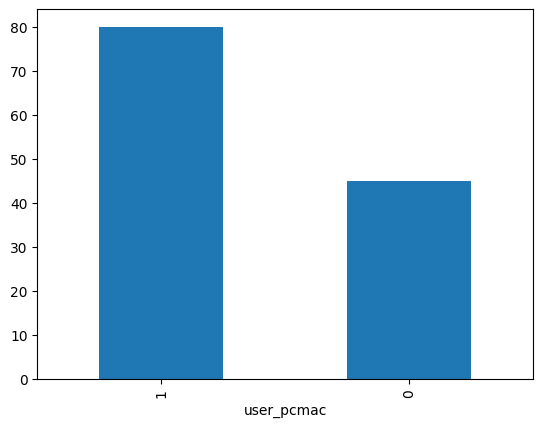

In [27]:
df['user_pcmac'].value_counts().plot(kind='bar')

**familiarity_m1**
Conclusions:
- a great number of people are unfamiliar with the product, yet many are familiar.

<Axes: xlabel='familiarity_m1'>

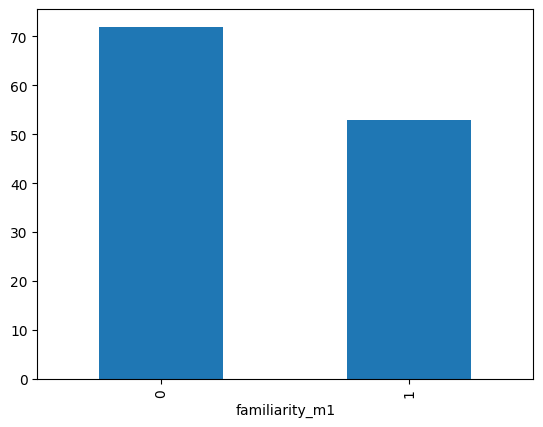

In [28]:
df['familiarity_m1'].value_counts().plot(kind='bar')

**gender**
Conclusions:
- most people are male which is expected

<Axes: xlabel='gender'>

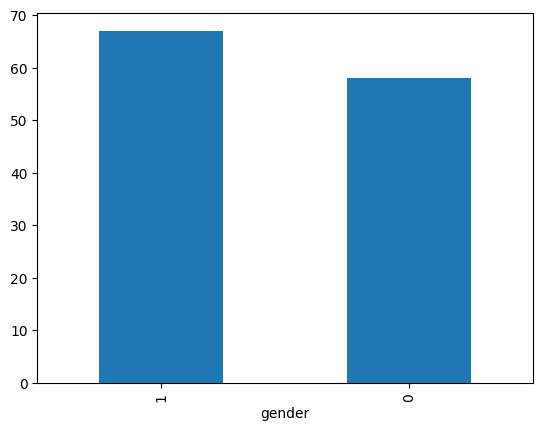

In [29]:
df['gender'].value_counts().plot(kind='bar')

**interest_computers**
Conclusions:
- Almost all people are moderately to highly interested in computers.

<Axes: xlabel='interest_computers'>

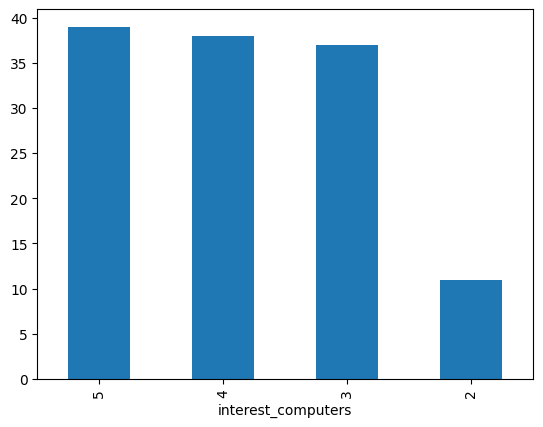

In [30]:
df['interest_computers'].value_counts().plot(kind='bar')

**f_batterylife**
Conclusions:
- Battery life matters to almost everyone.

<Axes: xlabel='f_batterylife'>

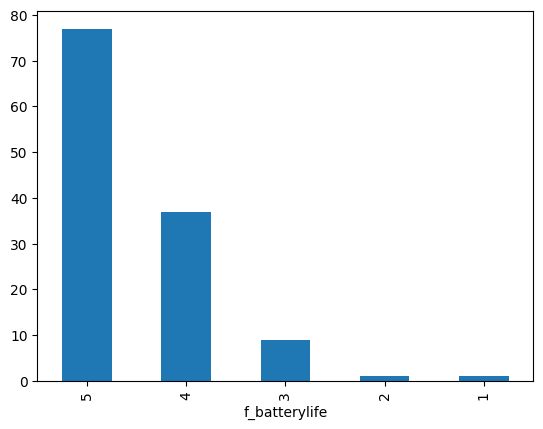

In [31]:
df['f_batterylife'].value_counts().plot(kind='bar')

**f_price**
Conclusions:
- The price is preferred from moderate to cheap.

<Axes: xlabel='f_price'>

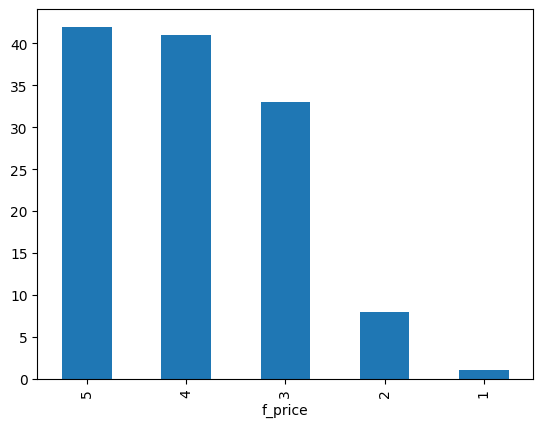

In [32]:
df['f_price'].value_counts().plot(kind='bar')

**f_size**
Conclusions:
- The thickness of the phone is considered moderately important.

<Axes: xlabel='f_size'>

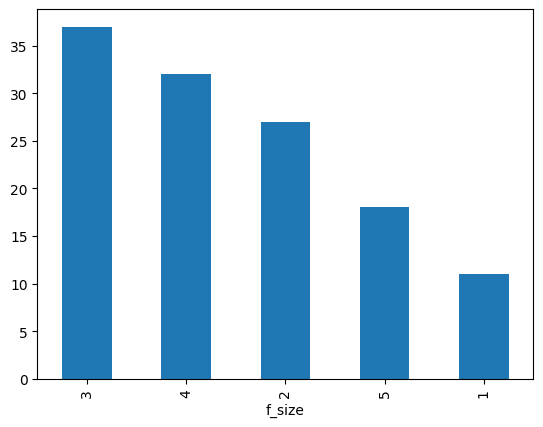

In [33]:
df['f_size'].value_counts().plot(kind='bar')

**f_multitasking**
Conclusions:
- The multitasking feature of the phone is highly preferred.

<Axes: xlabel='f_multitasking'>

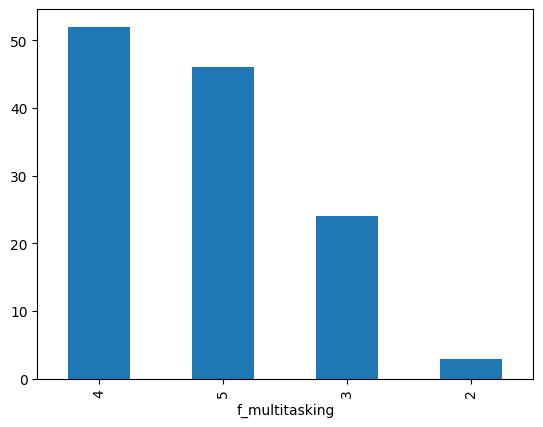

In [34]:
df['f_multitasking'].value_counts().plot(kind='bar')

**f_noise**
Conclusions:
- The noise cancellation feature is highly demanded.

<Axes: xlabel='f_noise'>

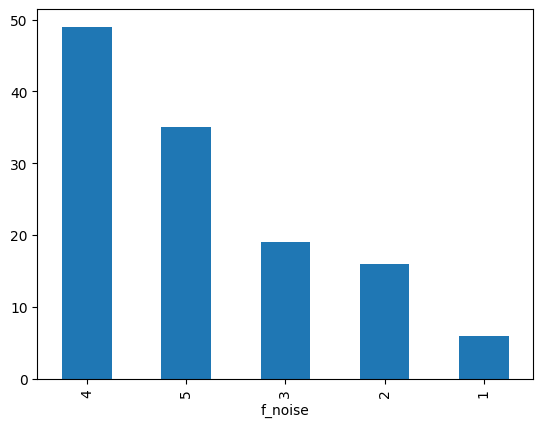

In [35]:
df['f_noise'].value_counts().plot(kind='bar')

**f_performance**
Conclusions:
- The performance improvement is highly preferred.

<Axes: xlabel='f_performance'>

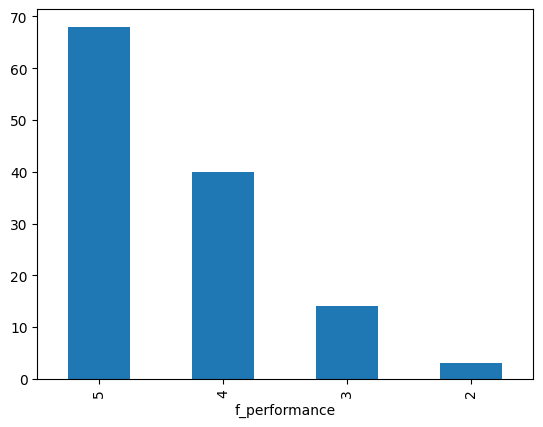

In [36]:
df['f_performance'].value_counts().plot(kind='bar')

**f_neural**
Conclusions:
- The neural engine preference is uniform.

<Axes: xlabel='f_neural'>

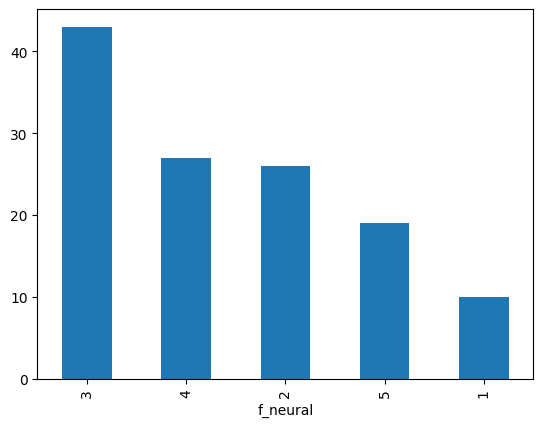

In [37]:
df['f_neural'].value_counts().plot(kind='bar')

**f_synergy**
Conclusions:
- A seamless performance is highly preferred.

<Axes: xlabel='f_synergy'>

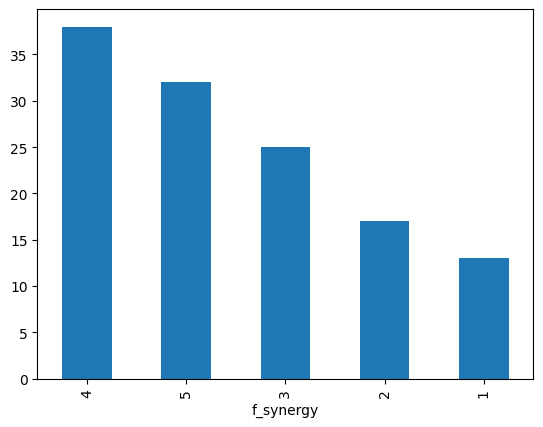

In [38]:
df['f_synergy'].value_counts().plot(kind='bar')

**f_performanceloss**
Conclusions:
- Even the small loss is important.

<Axes: xlabel='f_performanceloss'>

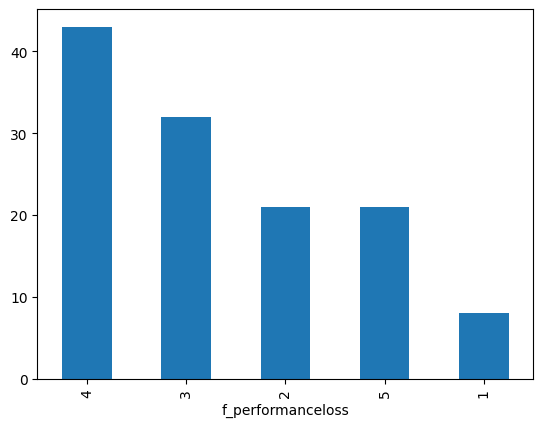

In [39]:
df['f_performanceloss'].value_counts().plot(kind='bar')

**m1_consideration**
Conclusions:
- The M1 is considered by many people.

<Axes: xlabel='m1_consideration'>

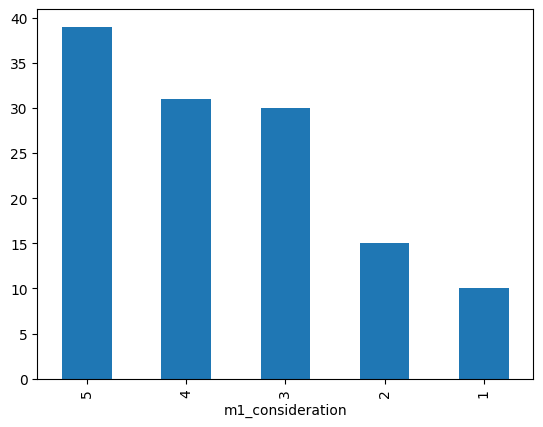

In [40]:
df['m1_consideration'].value_counts().plot(kind='bar')

**All the f variables and m1_consideration variable (customer feedback results) can be combined to form a single variable.**
PCA recommended

**age_group**
Conclusions:
- The age groups 2 and 3 consist of most of the population of our feedback form.

<Axes: xlabel='age_group'>

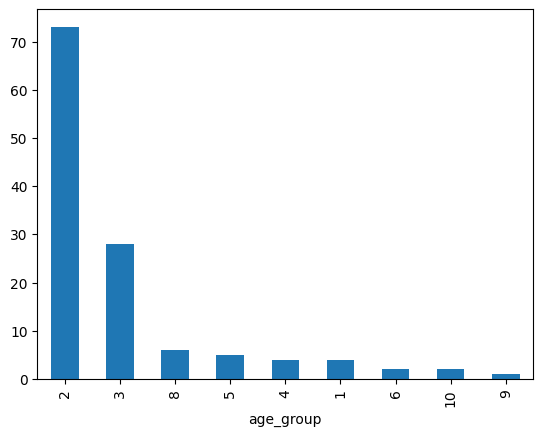

In [41]:
df['age_group'].value_counts().plot(kind='bar')

**income_group**
Conclusions:
- Age groups 1, 2, and 3 are in abundance in the feedback form, followed by 7 and 4.

<Axes: xlabel='income_group'>

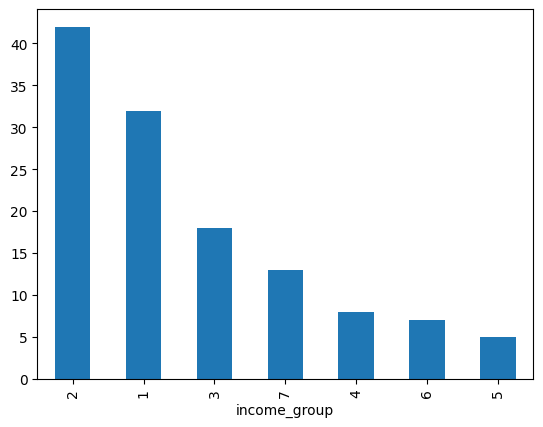

In [42]:
df['income_group'].value_counts().plot(kind='bar')

**status**
Conclusions:
- The feedback form has more students and employees.

<Axes: xlabel='status'>

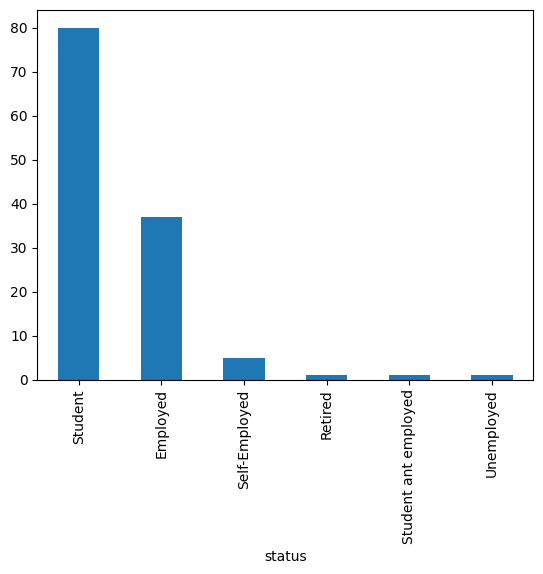

In [43]:
df['status'].value_counts().plot(kind='bar')

**domain**
Conclusions:
- Among the statuses, most people are from IT, marketing, and business.

<Axes: xlabel='domain'>

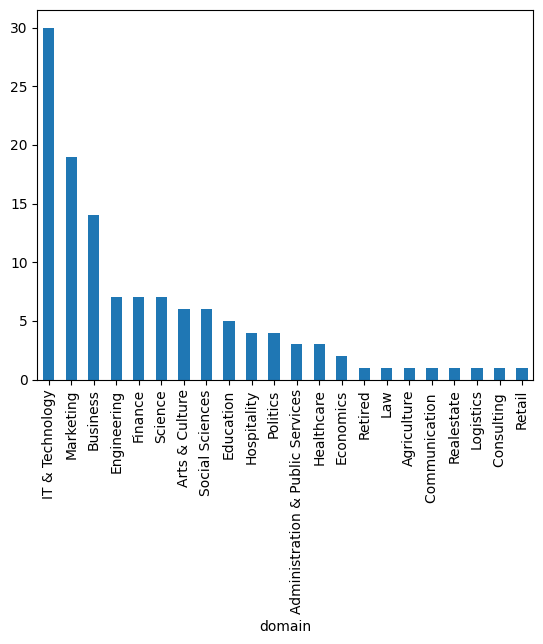

In [44]:
df['domain'].value_counts().plot(kind='bar')

**purchased**
Conclusions:
- The purchased variable is our target, which is significantly imbalanced.

<Axes: xlabel='purchased'>

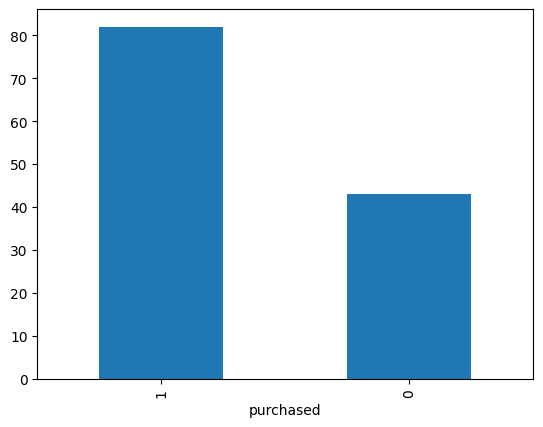

In [45]:
df['purchased'].value_counts().plot(kind='bar')

**Bi-variate Analysis.**

In [46]:
pd.crosstab(df['domain'],df['purchased'], normalize='index')*100

purchased,0,1
domain,,
Administration & Public Services,0.000000,100.000000
Agriculture,0.000000,100.000000
Arts & Culture,50.000000,50.000000
Business,42.857143,57.142857
Communication,100.000000,0.000000
Consulting,100.000000,0.000000
Economics,0.000000,100.000000
Education,20.000000,80.000000
Engineering,28.571429,71.428571


In [47]:
pd.crosstab(df['status'],df['purchased'], normalize='index')*100

purchased,0,1
status,,
Employed,35.135135,64.864865
Retired,0.000000,100.000000
Self-Employed,40.000000,60.000000
Student,35.000000,65.000000
Student ant employed,0.000000,100.000000
Unemployed,0.000000,100.000000


In [48]:
pd.crosstab(df['income_group'],df['purchased'], normalize='index')*100

purchased,0,1
income_group,,
1,37.500000,62.500000
2,30.952381,69.047619
3,55.555556,44.444444
4,37.500000,62.500000
5,0.000000,100.000000
6,0.000000,100.000000
7,38.461538,61.538462


In [49]:
pd.crosstab(df['age_group'],df['purchased'], normalize='index')*100

purchased,0,1
age_group,,
1,0.000000,100.000000
2,35.616438,64.383562
3,42.857143,57.142857
4,25.000000,75.000000
5,40.000000,60.000000
6,0.000000,100.000000
8,16.666667,83.333333
9,0.000000,100.000000
10,50.000000,50.000000


In [50]:
pd.crosstab(df['gender'],df['purchased'], normalize='index')*100

purchased,0,1
gender,,
0,37.931034,62.068966
1,31.343284,68.656716


In [51]:
pd.crosstab(df['trust_apple'],df['purchased'], normalize='index')*100

purchased,0,1
trust_apple,,
0,63.157895,36.842105
1,29.245283,70.754717


In [52]:
pd.crosstab(df['interest_computers'],df['purchased'], normalize='index')*100

purchased,0,1
interest_computers,,
2,36.363636,63.636364
3,43.243243,56.756757
4,28.947368,71.052632
5,30.769231,69.230769


In [53]:
pd.crosstab(df['age_computer'],df['purchased'], normalize='index')*100

purchased,0,1
age_computer,,
0,21.212121,78.787879
1,60.000000,40.000000
2,38.461538,61.538462
3,25.000000,75.000000
4,50.000000,50.000000
5,14.285714,85.714286
6,42.857143,57.142857
7,66.666667,33.333333
8,0.000000,100.000000


In [54]:
pd.crosstab(df['user_pcmac'],df['purchased'], normalize='index')*100

purchased,0,1
user_pcmac,,
0,60.0,40.0
1,20.0,80.0


In [55]:
pd.crosstab(df['appleproducts_count'],df['purchased'], normalize='index')*100

purchased,0,1
appleproducts_count,,
0,65.217391,34.782609
1,53.333333,46.666667
2,33.333333,66.666667
3,16.666667,83.333333
4,25.000000,75.000000
5,20.000000,80.000000
6,0.000000,100.000000
7,40.000000,60.000000
8,0.000000,100.000000


In [56]:
pd.crosstab(df['familiarity_m1'],df['purchased'], normalize='index')*100

purchased,0,1
familiarity_m1,,
0,43.055556,56.944444
1,22.641509,77.358491


In [57]:
pd.crosstab(df['familiarity_m1'],df['trust_apple'], normalize='index')*100

trust_apple,0,1
familiarity_m1,,
0,15.277778,84.722222
1,15.094340,84.905660


In [58]:
pd.crosstab(df['age_computer'],df['appleproducts_count'], normalize='index')*100

appleproducts_count,0,1,2,3,4,5,6,7,8
age_computer,,,,,,,,,
0,21.212121,12.121212,15.151515,27.272727,18.181818,0.000000,0.000000,3.030303,3.030303
1,20.000000,6.666667,33.333333,26.666667,13.333333,0.000000,0.000000,0.000000,0.000000
2,15.384615,23.076923,0.000000,15.384615,7.692308,7.692308,15.384615,15.384615,0.000000
3,15.000000,5.000000,20.000000,45.000000,10.000000,5.000000,0.000000,0.000000,0.000000
4,25.000000,12.500000,0.000000,12.500000,12.500000,0.000000,12.500000,25.000000,0.000000
5,14.285714,14.285714,7.142857,42.857143,14.285714,7.142857,0.000000,0.000000,0.000000
6,7.142857,7.142857,35.714286,35.714286,14.285714,0.000000,0.000000,0.000000,0.000000
7,33.333333,0.000000,33.333333,0.000000,0.000000,33.333333,0.000000,0.000000,0.000000
8,50.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000


In [59]:
pd.crosstab(df['f_batterylife'],df['purchased'], normalize='index')*100

purchased,0,1
f_batterylife,,
1,100.000000,0.000000
2,0.000000,100.000000
3,22.222222,77.777778
4,45.945946,54.054054
5,29.870130,70.129870


In [60]:
pd.crosstab(df['f_price'],df['purchased'], normalize='index')*100

purchased,0,1
f_price,,
1,0.000000,100.000000
2,25.000000,75.000000
3,30.303030,69.696970
4,29.268293,70.731707
5,45.238095,54.761905


In [61]:
pd.crosstab(df['f_size'],df['purchased'], normalize='index')*100

purchased,0,1
f_size,,
1,36.363636,63.636364
2,33.333333,66.666667
3,24.324324,75.675676
4,46.875000,53.125000
5,33.333333,66.666667


In [62]:
pd.crosstab(df['f_multitasking'],df['purchased'], normalize='index')*100

purchased,0,1
f_multitasking,,
2,33.333333,66.666667
3,37.500000,62.500000
4,38.461538,61.538462
5,28.260870,71.739130


In [63]:
pd.crosstab(df['f_neural'],df['purchased'], normalize='index')*100

purchased,0,1
f_neural,,
1,20.000000,80.000000
2,38.461538,61.538462
3,39.534884,60.465116
4,29.629630,70.370370
5,31.578947,68.421053


In [64]:
pd.crosstab(df['f_synergy'],df['purchased'], normalize='index')*100

purchased,0,1
f_synergy,,
1,61.538462,38.461538
2,35.294118,64.705882
3,32.000000,68.000000
4,34.210526,65.789474
5,25.000000,75.000000


In [65]:
pd.crosstab(df['f_performanceloss'],df['purchased'], normalize='index')*100

purchased,0,1
f_performanceloss,,
1,25.000000,75.000000
2,23.809524,76.190476
3,46.875000,53.125000
4,32.558140,67.441860
5,33.333333,66.666667


In [66]:
pd.crosstab(df['f_performance'],df['purchased'], normalize='index')*100

purchased,0,1
f_performance,,
2,0.000000,100.000000
3,28.571429,71.428571
4,37.500000,62.500000
5,35.294118,64.705882


In [67]:
pd.crosstab(df['f_noise'],df['purchased'], normalize='index')*100

purchased,0,1
f_noise,,
1,33.333333,66.666667
2,50.000000,50.000000
3,36.842105,63.157895
4,30.612245,69.387755
5,31.428571,68.571429


In [68]:
pd.crosstab(df['age_group'],df['income_group'])

income_group,1,2,3,4,5,6,7
age_group,,,,,,,
1,0,4,0,0,0,0,0
2,25,30,11,3,3,1,0
3,7,5,7,3,1,3,2
4,0,3,0,0,0,1,0
5,0,0,0,1,0,1,3
6,0,0,0,0,0,1,1
8,0,0,0,1,1,0,4
9,0,0,0,0,0,0,1
10,0,0,0,0,0,0,2


In [69]:
pd.crosstab(df['age_group'],df['status'])

status,Employed,Retired,Self-Employed,Student,Student ant employed,Unemployed
age_group,,,,,,
1,0,0,0,4,0,0
2,9,0,0,63,1,0
3,15,0,1,12,0,0
4,1,0,1,1,0,1
5,4,0,1,0,0,0
6,2,0,0,0,0,0
8,3,1,2,0,0,0
9,1,0,0,0,0,0
10,2,0,0,0,0,0


In [70]:
pd.crosstab(df['status'],df['income_group'])

income_group,1,2,3,4,5,6,7
status,,,,,,,
Employed,0,2,8,6,3,6,12
Retired,0,0,0,1,0,0,0
Self-Employed,0,2,0,0,1,1,1
Student,32,37,10,1,0,0,0
Student ant employed,0,0,0,0,1,0,0
Unemployed,0,1,0,0,0,0,0


In [71]:
pd.crosstab(df['domain'],df['income_group'])

income_group,1,2,3,4,5,6,7
domain,,,,,,,
Administration & Public Services,0,1,0,0,1,0,1
Agriculture,0,1,0,0,0,0,0
Arts & Culture,0,4,1,0,0,0,1
Business,8,2,1,1,1,0,1
Communication,1,0,0,0,0,0,0
Consulting,1,0,0,0,0,0,0
Economics,1,1,0,0,0,0,0
Education,0,0,1,0,1,1,2
Engineering,0,4,3,0,0,0,0


In [72]:
pd.crosstab(df['familiarity_m1'],df['m1_consideration'], normalize='columns')*100

m1_consideration,1,2,3,4,5
familiarity_m1,,,,,
0,80.0,86.666667,76.666667,64.516129,20.512821
1,20.0,13.333333,23.333333,35.483871,79.487179


In [73]:
df[(df['familiarity_m1']==1) & (df['m1_consideration']==5)]['purchased'].value_counts()

purchased
1    28
0     3
Name: count, dtype: int64

In [74]:
df[df['user_pcmac']==1]['appleproducts_count'].value_counts()

appleproducts_count
3    30
4    16
2    15
7     5
5     5
1     5
6     3
8     1
Name: count, dtype: int64

In [75]:
df[df['trust_apple']==1]['interest_computers'].value_counts()

interest_computers
4    34
3    31
5    30
2    11
Name: count, dtype: int64

In [76]:
df[df['user_pcmac']==1]['age_computer'].value_counts()

age_computer
0    22
3    15
6    11
5    10
1     7
2     7
4     5
7     2
8     1
Name: count, dtype: int64

In [77]:
pd.crosstab(df['user_pcmac'],df['age_computer'], normalize='columns')*100

age_computer,0,1,2,3,4,5,6,7,8,9
user_pcmac,,,,,,,,,,
0,33.333333,53.333333,46.153846,25.0,37.5,28.571429,21.428571,33.333333,50.0,100.0
1,66.666667,46.666667,53.846154,75.0,62.5,71.428571,78.571429,66.666667,50.0,0.0


In [78]:
pd.crosstab(df['trust_apple'],df['user_pcmac'], normalize='columns')*100

user_pcmac,0,1
trust_apple,,
0,28.888889,7.5
1,71.111111,92.5


In [79]:
df.drop(columns=['f_noise', 'f_performance','f_performanceloss', 'f_synergy', 'f_neural', 'f_multitasking', 'f_size', 'f_price', 'f_batterylife'])

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,m1_consideration,gender,age_group,income_group,status,domain,purchased
0,0,4,8,0,0,0,1,1,2,2,Student,Science,1
1,1,2,4,0,1,0,2,1,2,3,Employed,Finance,0
2,1,5,6,0,0,0,4,1,2,2,Student,IT & Technology,1
3,1,2,6,1,4,0,2,0,2,2,Student,Arts & Culture,0
4,1,4,4,1,7,1,4,1,5,7,Employed,Hospitality,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,1,5,0,0,1,1,5,1,3,3,Student,Engineering,1
129,1,5,8,1,5,1,5,1,3,5,Employed,Administration & Public Services,1
130,1,4,0,1,8,1,5,0,2,3,Student,Marketing,1
131,1,5,5,1,4,1,5,0,2,2,Student,IT & Technology,1


**Multivariate Analysis**

Conclusion:
- There is a strong positive correlation between the number of Apple products a person owns (appleproducts_count) and their primary computer type (user_pcmac).
- Age group and income group show a moderate positive correlation, indicating older users in this dataset tend to have higher incomes.
- Familiarity with the M1 chip (familiarity_m1) is positively linked to both a general interest in computers and the likelihood of considering an M1 purchase (m1_consideration).
- Performance-related features (f_multitasking, f_noise, f_performance, and f_neural) show positive correlations with each other, suggesting users value or evaluate these technical specs as a combined package.
- The actual purchased variable has generally weak correlations across the board, showing only very mild positive links to prior M1 consideration and being a current Mac user.

In [82]:
df.head()

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_neural,f_synergy,f_performanceloss,m1_consideration,gender,age_group,income_group,status,domain,purchased
0,0,4,8,0,0,0,5,4,3,4,...,2,1,1,1,1,2,2,Student,Science,1
1,1,2,4,0,1,0,5,5,5,3,...,2,2,4,2,1,2,3,Employed,Finance,0
2,1,5,6,0,0,0,3,4,2,4,...,2,2,2,4,1,2,2,Student,IT & Technology,1
3,1,2,6,1,4,0,4,3,3,4,...,4,4,3,2,0,2,2,Student,Arts & Culture,0
4,1,4,4,1,7,1,5,3,3,4,...,3,4,4,4,1,5,7,Employed,Hospitality,1


<Axes: >

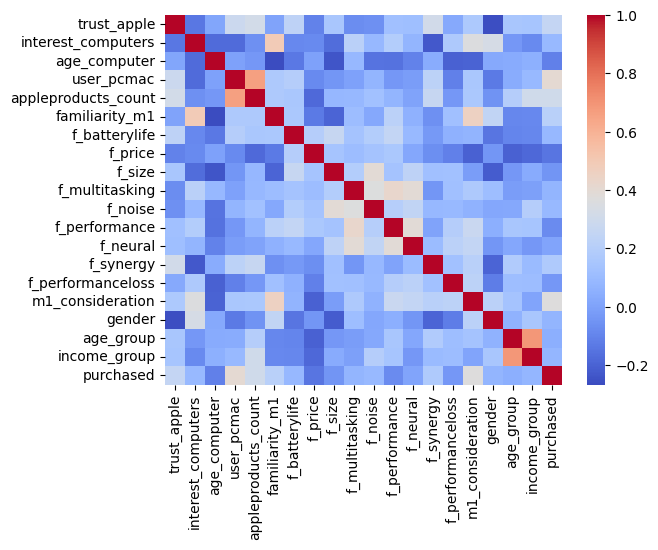

In [86]:
sns.heatmap(df.drop(columns=['status', 'domain']).corr(), cmap='coolwarm')